In [55]:
from methylseqnet import dna_io, inference
from dimelo import load_processed, plot_enrichment_profile
from matplotlib import pyplot as plt
import torch
import numpy as np
from Bio import motifs, Seq
import pysam

In [2]:
ref_genome = '/clusterfs/nilah/oberon/jupyter/chm13.draft_v1.0.fasta'
CpG_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/cpg_bam_whole_genome/pileup.sorted.bed.gz'
mA_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/allcontext_bam_whole_genome/pileup.sorted.bed.gz'

In [48]:
with open('/clusterfs/nilah/oberon/datasets/motifs/MA0139.1_forward.pfm','r') as f:
    forward_pfm = motifs.read(f,'pfm',strict=False)
with open('/clusterfs/nilah/oberon/datasets/motifs/MA0139.1_reverse.pfm','r') as f:
    reverse_pfm = motifs.read(f,'pfm')
forward_pwm = forward_pfm.counts.normalize(pseudocounts=0.1).log_odds()
reverse_pwm = reverse_pfm.counts.normalize(pseudocounts=0.1).log_odds()

In [26]:
pileup_hp1_nmp = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/chrX_hp1_processed/pileup.sorted.bed.gz'
pileup_hp2_nmp = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/chrX_hp2_processed/pileup.sorted.bed.gz'
pileup_hp1 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_cpg/pileup.sorted.bed.gz'
pileup_hp2 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_cpg/pileup.sorted.bed.gz'
pileup_hp1_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_ma/pileup.sorted.bed.gz'
pileup_hp2_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_ma/pileup.sorted.bed.gz'

In [27]:
model_paths = [
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-12-34_in4',
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-13-35_in5',
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-33-39_in1',
]

In [28]:
models = [inference.load_for_eval(model_path) for model_path in model_paths]

In [41]:
chromosome = 'chrX'
start = 130064000
end = 130080000
# start = 37_728_599
# end = 37_733_817

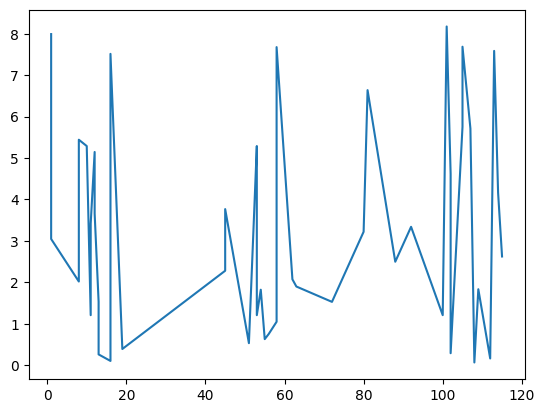

In [62]:
ref_fasta = pysam.FastaFile(ref_genome)
matches = list(forward_pwm.search(Seq.Seq(ref_fasta.fetch(chromosome,start,end))))
match_positions = []
match_values = []
for match in matches:
    if match[0]>0:
        match_positions.append(match[0]//128)
        match_values.append(match[1])
plt.plot(match_positions,match_values)

In [42]:
onehot_inputs = []
onehot_hp1 = []
onehot_hp2 = []
for chunk_start in range(start,end,128):
    onehot_inputs.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=CpG_pileup,
        )
    )
    onehot_hp1.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp1,
        )
    )
    onehot_hp2.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp2,
        )
    )

<Axes: xlabel='pos', ylabel='fraction modified bases'>

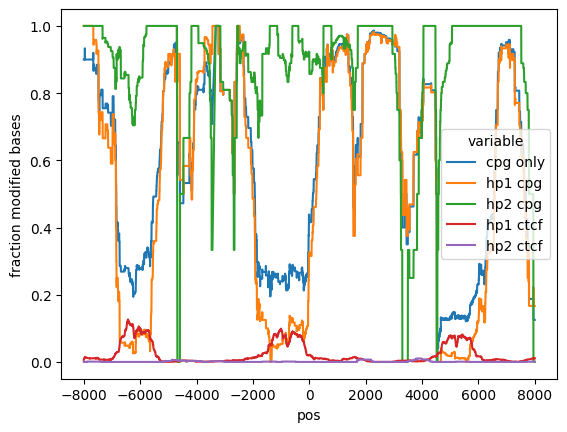

In [46]:
region = f'{chromosome}:{start}-{end}'
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [CpG_pileup,pileup_hp1,pileup_hp2,pileup_hp1_allcontext,pileup_hp2_allcontext],#pileup_hp1_nmp,pileup_hp2_nmp],
    regions_list = [region,region,region,region,region],#region,region],
    sample_names = ['cpg only','hp1 cpg','hp2 cpg','hp1 ctcf','hp2 ctcf'],#'hp1 guppy','hp2 guppy'],
    motifs = ['CG,0','CG,0','CG,0','A,0','A,0'],#'CG,0','CG,0'],
    window_size = None,
    smooth_window = 500,
)
# samtools view -N qnames_list.txt -o filtered_output.bam input.bam, requires samtools 1.12 or greater

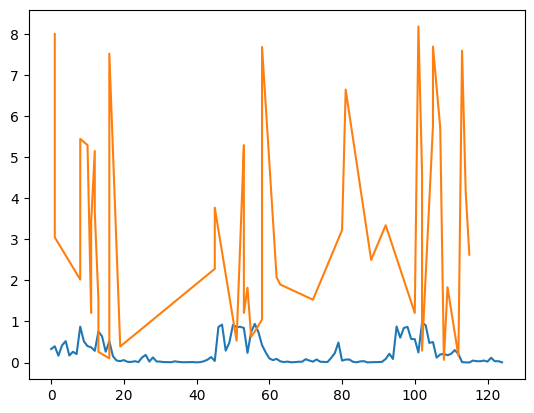

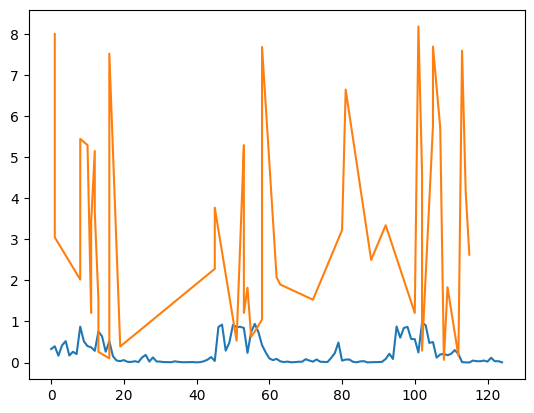

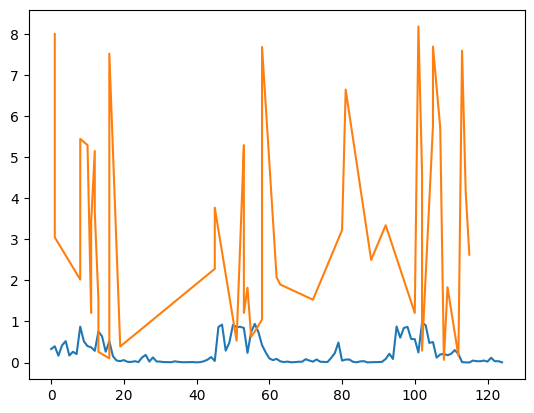

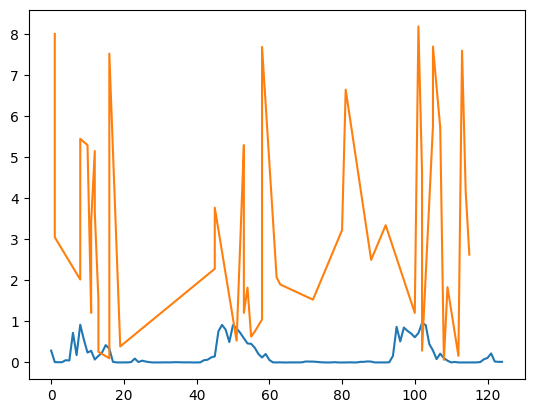

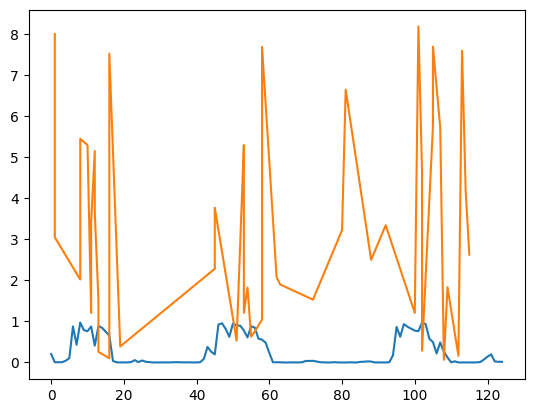

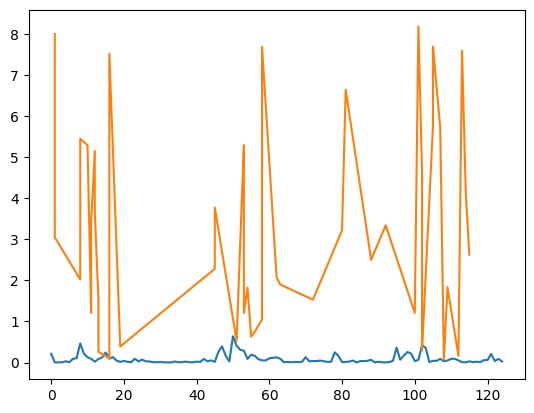

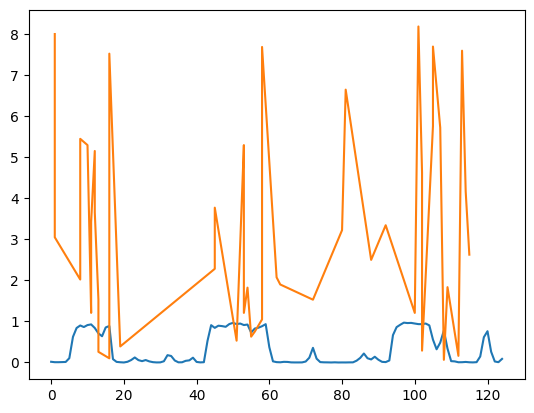

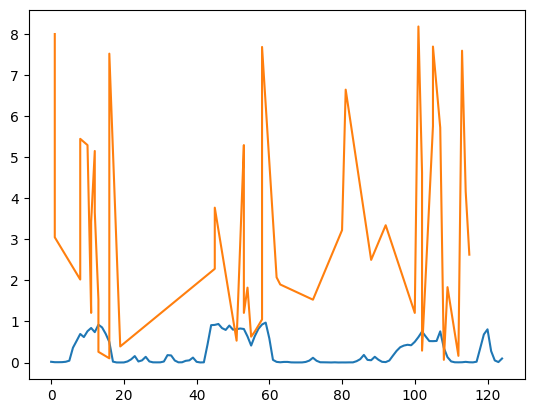

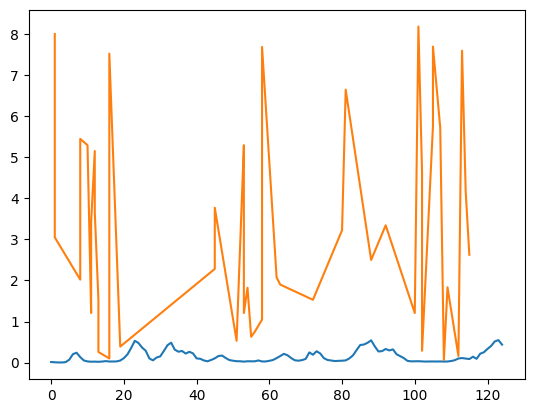

In [63]:
# print(np.array(onehot_hp2).shape)
# print(np.array(onehot_hp2).shape)
# onehot_hp2 = np.array(onehot_hp2)
# onehot_hp2[:,:,-1] = 0.7
for model in models:
    for onehot in [onehot_inputs,onehot_hp1,onehot_hp2]:
        predictions = torch.sigmoid(model(torch.tensor(np.transpose(np.array(onehot), (0,2,1)),dtype=torch.float32)).detach())
        plt.plot(np.array(predictions))
        plt.plot(match_positions,match_values)
        plt.show()